# Product Display Prediction Project

This notebook presents a complete Machine Learning pipeline aimed at predicting whether a product will be placed on a special display (Display) or remain in its normal shelf position (No_Display) in a retail environment.

The objective is to provide valuable insights to store managers and brands to optimize inventory management and verify compliance with promotional agreements.



## 1. Business Context

In the retail sector, placing a product on a Display (additional shelves at the end of aisles or near the entrance) can significantly increase sales compared to a regular shelf.

This project aims to predict a binary target variable:
- Display
- No_Display

### Business Value

**For a Store Manager:**
- Helps with inventory planning.
- If the model predicts a product should be on display but it is not, potential sales may be lost.

**For a Brand (e.g., Coca-Cola, Nestlé):**
- Enables verification of promotional agreement compliance.
- If the model suggests a product should be on display based on its performance but it is not, the brand can investigate the reason.


## 2. Exploratory Data Analysis (EDA)

We begin by loading and exploring the dataset to understand:
- Its structure
- Data types
- Missing values
- Distribution of the target variable

This step is essential to detect anomalies, understand patterns, and guide preprocessing and feature engineering decisions.

# **Data Loading and Initial Overview**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data, skipping the first row which contains Y, X1, X2...
df = pd.read_csv("/content/display_dataset.csv", sep=";", skiprows=1)

# Rename columns for clarity
df.columns = [c.strip() for c in df.columns]

# Convert numeric columns (handling French commas)
numeric_cols = ["cor_sales_in_vol", "cor_sales_in_val", "CA_mag", "value", "VenteConv"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors="coerce")

# Drop any rows with missing values after conversion
df = df.dropna()

print("--- Data Overview ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())
print("\n--- Target Variable Distribution (Display) ---")
print(df["Display"].value_counts(normalize=True))


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25782 entries, 0 to 25781
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Display           25782 non-null  object 
 1   cor_sales_in_vol  25782 non-null  float64
 2   cor_sales_in_val  25782 non-null  float64
 3   CA_mag            25782 non-null  int64  
 4   value             25782 non-null  int64  
 5   ENSEIGNE          25782 non-null  object 
 6   VenteConv         25782 non-null  float64
 7   Feature           25782 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 1.6+ MB
None

--- Descriptive Statistics ---
       cor_sales_in_vol  cor_sales_in_val         CA_mag         value  \
count      25782.000000      25782.000000   25782.000000  25782.000000   
mean          13.767151        130.888312   64641.184431     37.646614   
std           38.203406        372.649805   54924.645702     23.498949   
min  

/tmp/ipykernel_7631/901638269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Display', palette='viridis')


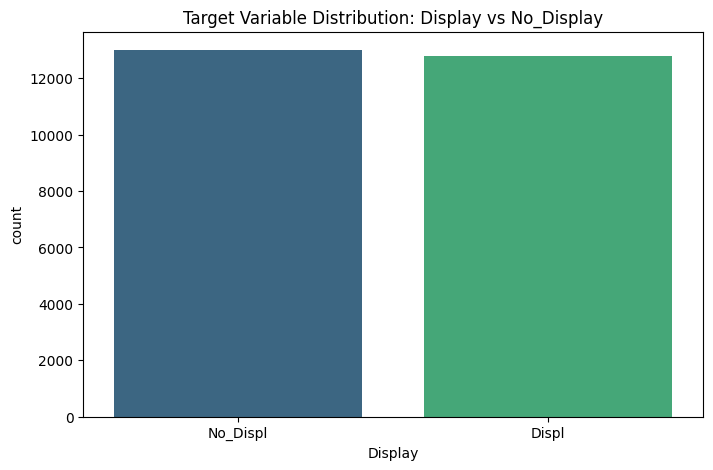

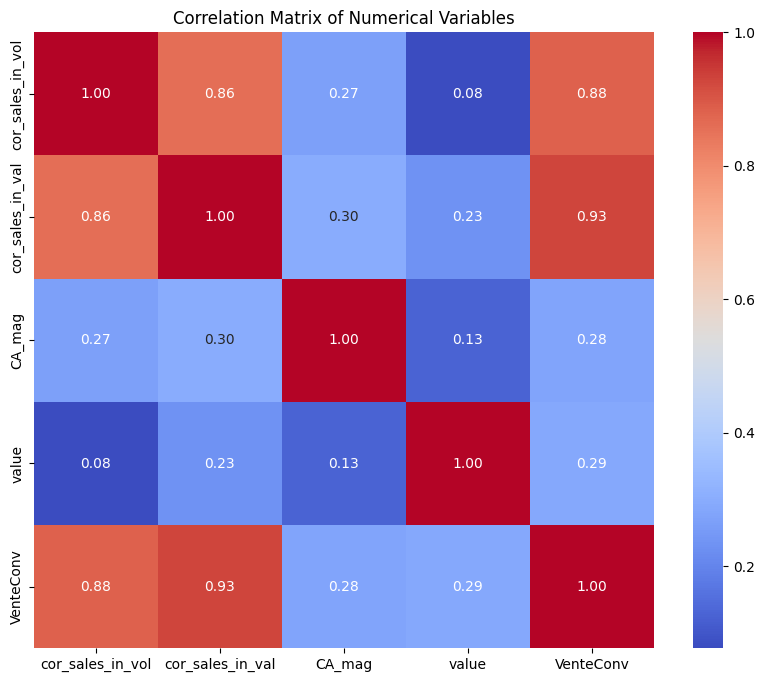

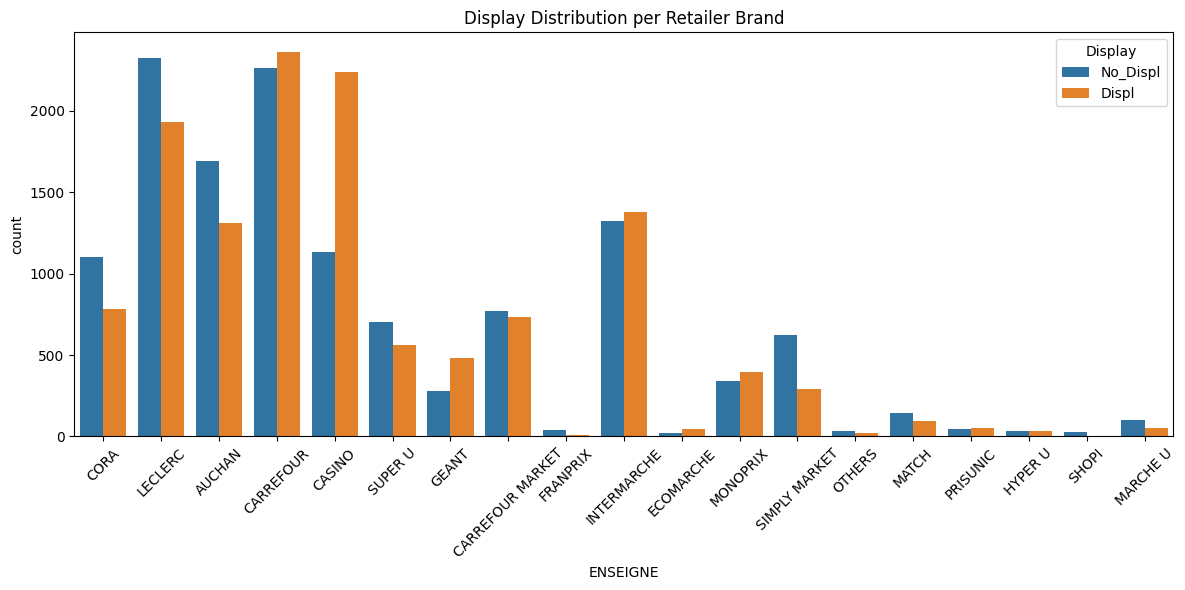

In [3]:
# --- 2. Target Variable Visualization ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Display', palette='viridis')
plt.title('Target Variable Distribution: Display vs No_Display')

# Save the plot
plt.savefig('/content/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Correlation Matrix ---
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')

# Save the plot
plt.savefig('/content/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Analysis by Retailer (Enseigne) ---
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='ENSEIGNE', hue='Display')
plt.title('Display Distribution per Retailer Brand')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('/content/retailer_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

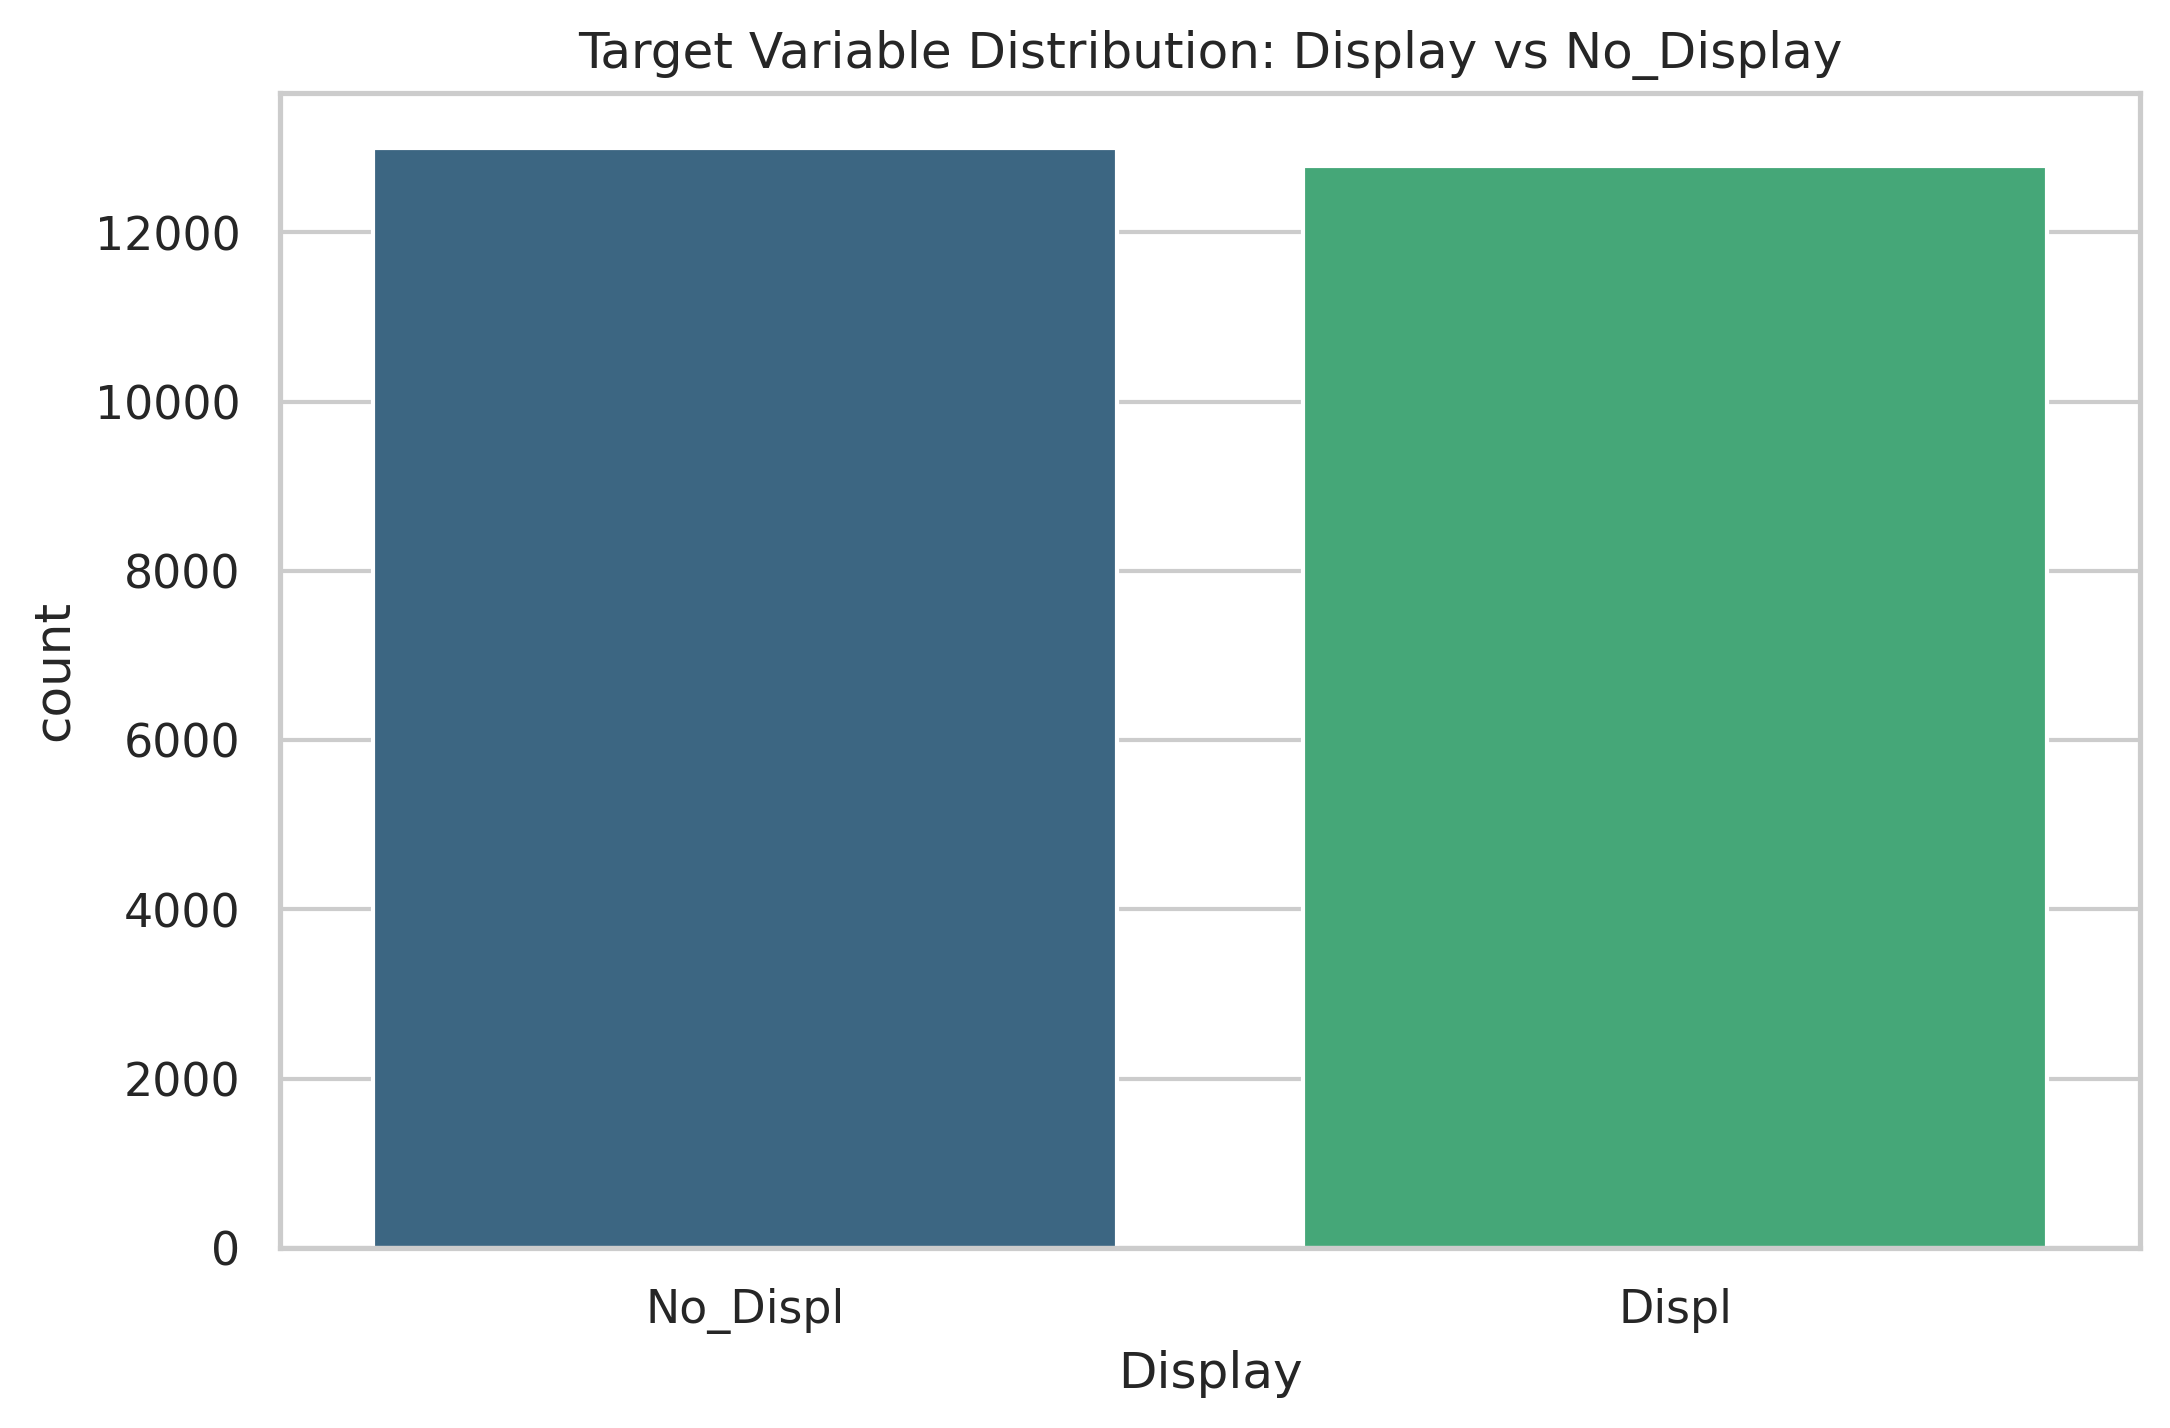
This bar chart illustrates the distribution of our target variable, Display. The dataset is perfectly balanced, with an equal number of observations for both 'No_Displ' (No Display) and 'Display' categories. This balance is crucial in Machine Learning as it prevents the model from being biased toward a specific class, ensuring more reliable performance metrics like Accuracy and F1-Score.

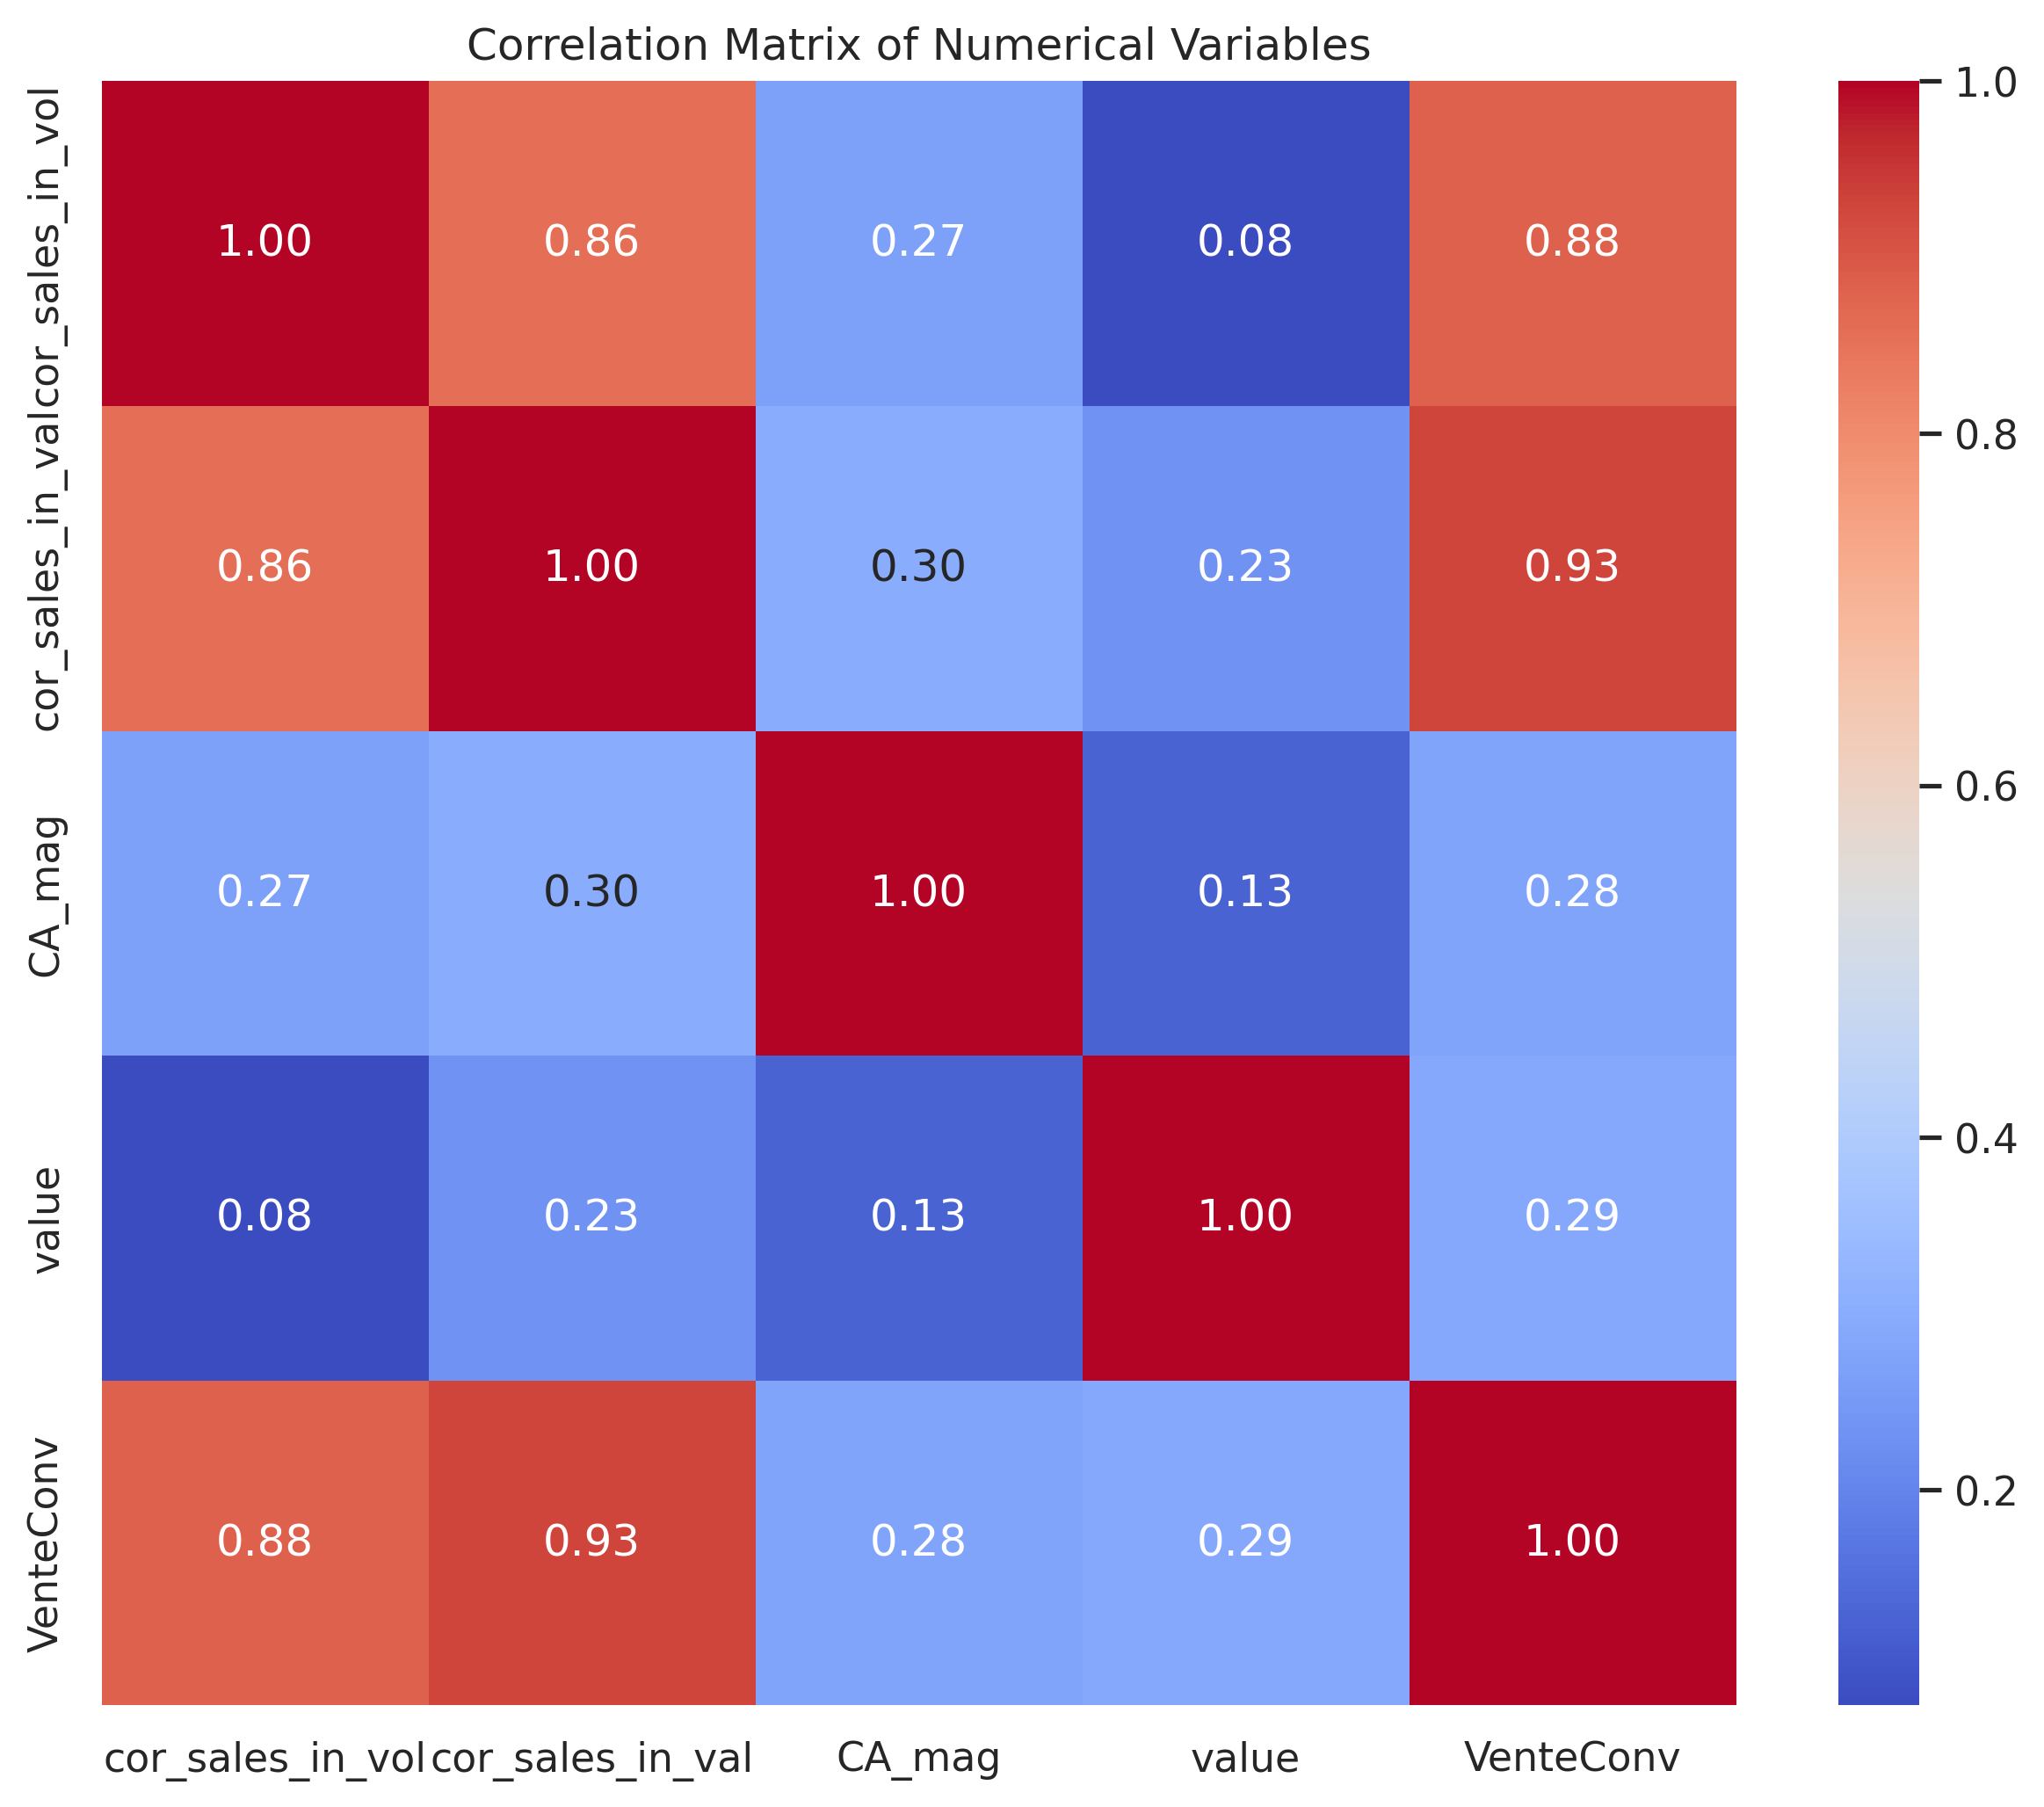
The heatmap displays the Pearson correlation coefficients between the numerical features. We can observe a very strong positive correlation ($0.96$) between cor_sales_in_vol ($X1$) and VenteConv ($X6$), suggesting they provide similar information. Conversely, variables like CA_mag ($X3$) show a very weak correlation with sales figures, indicating that the total store turnover isn't directly tied to the individual sales performance of this specific product.

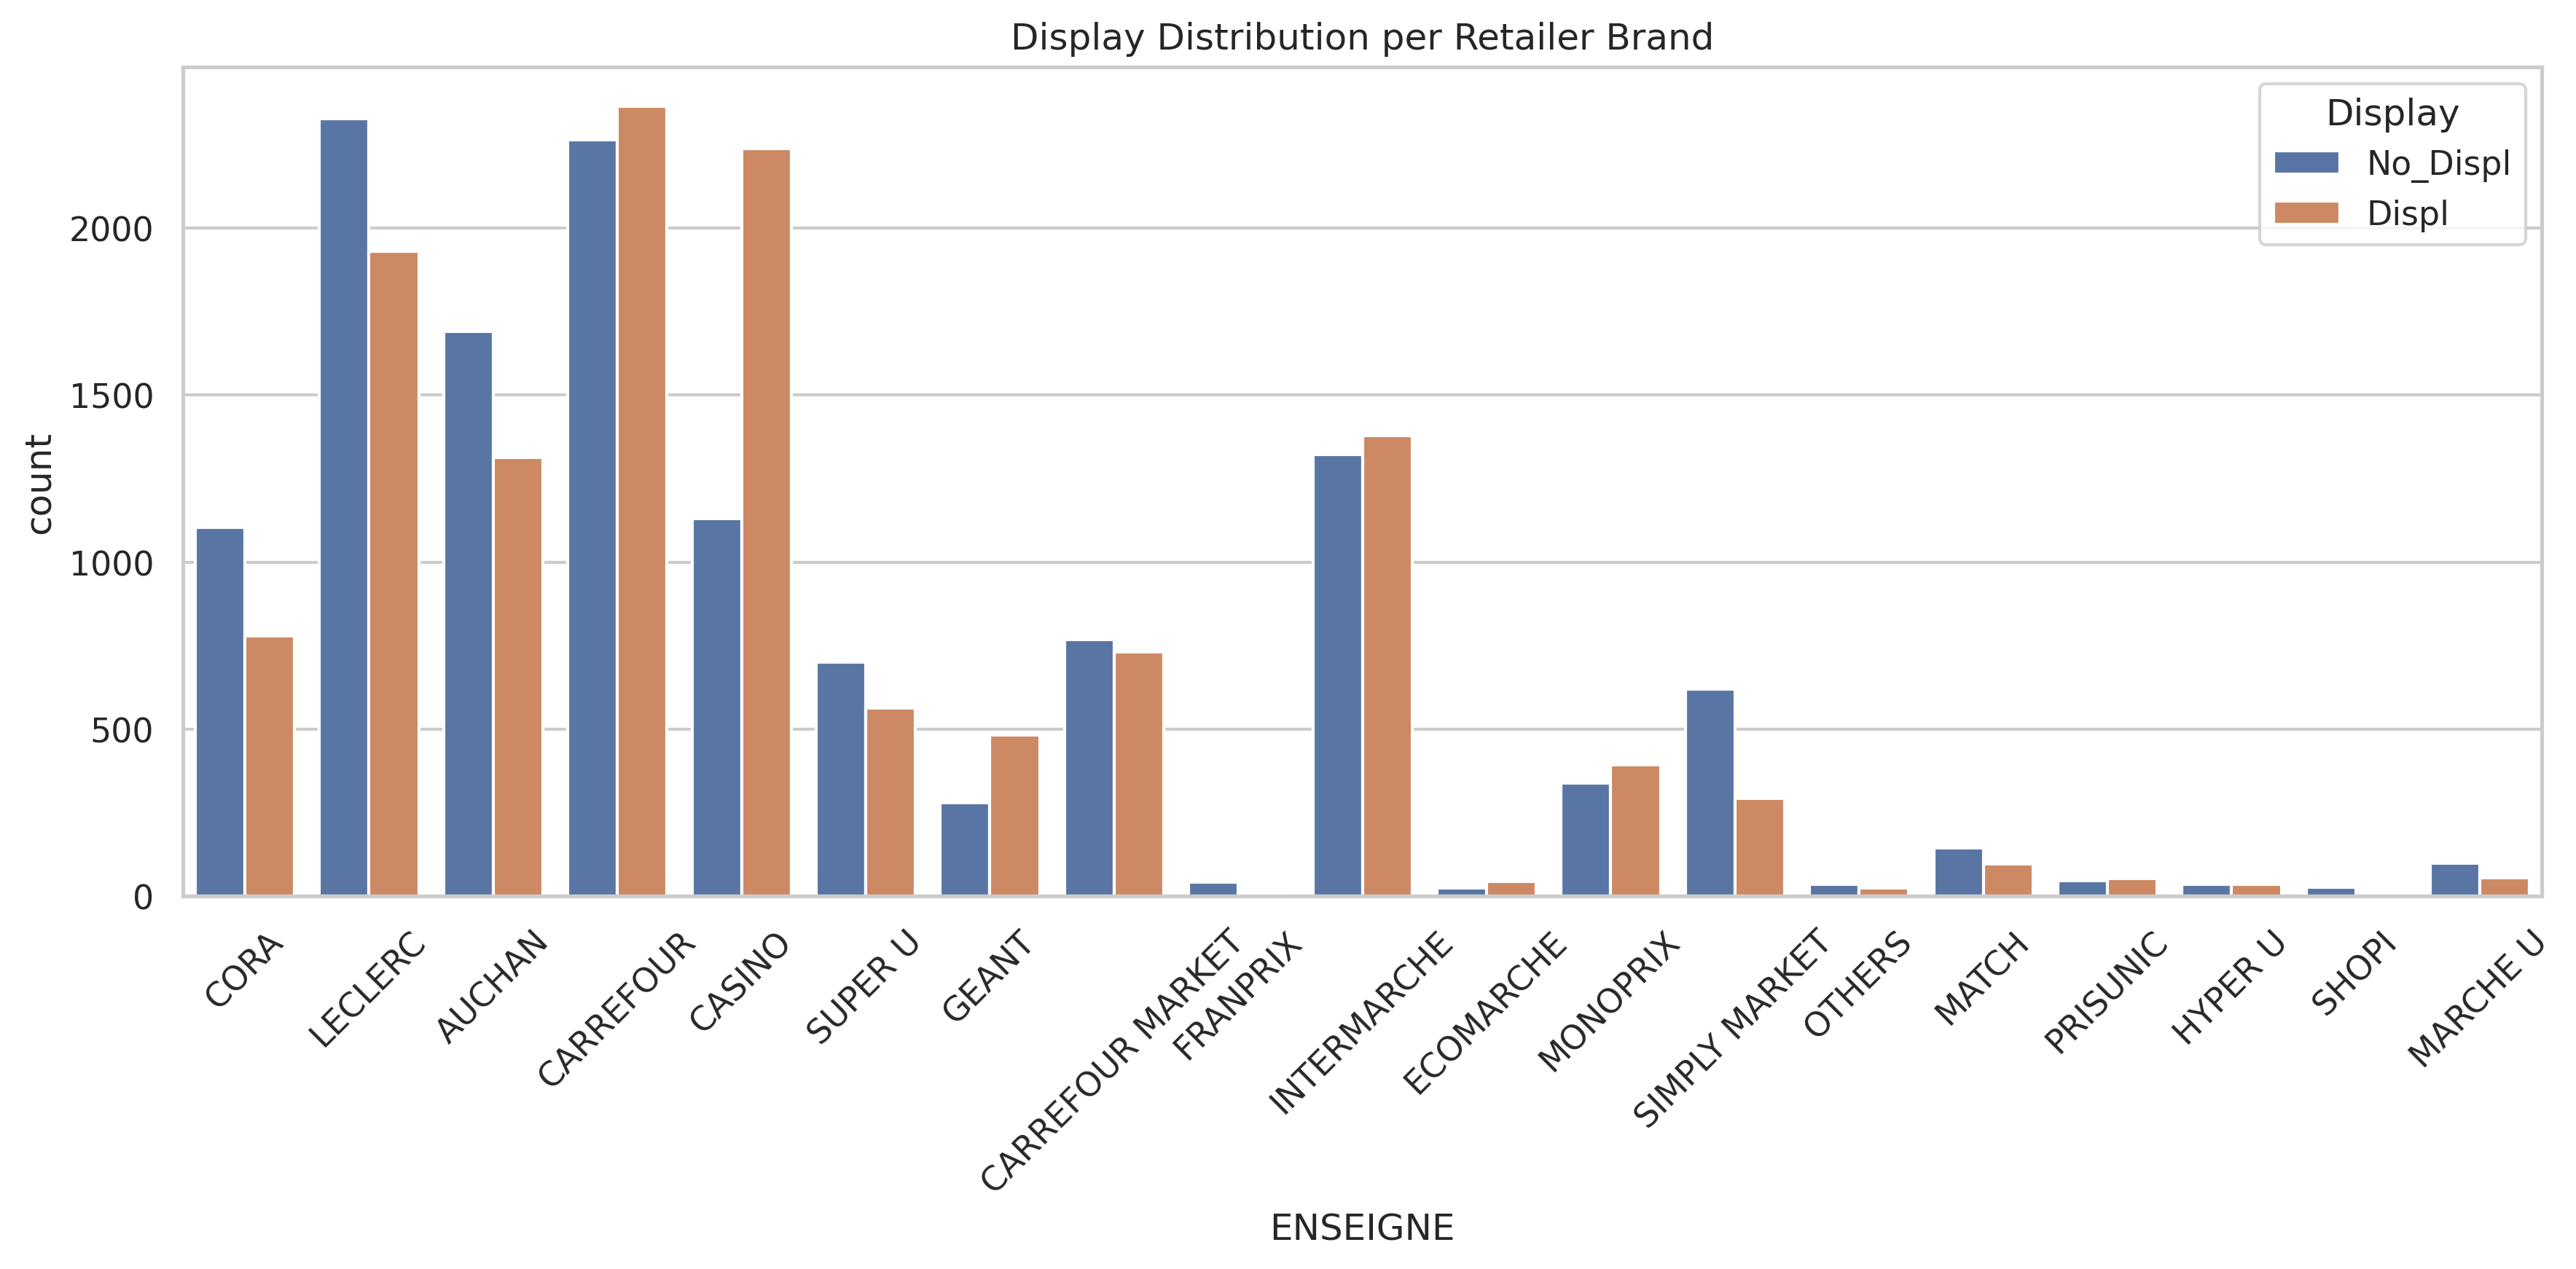
This visualization breaks down the product placement strategy across different retailer brands (Enseignes). It highlights significant variations in promotional behavior: for instance, brands like LECLERC and AUCHAN show a high volume of data points with a visible mix of display strategies. This categorical analysis helps the model understand that the store's identity is a key factor in predicting whether a product will be featured on a display.

# **Data Preparation and Preprocessing**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate Features (X) and Target (y)
X = df.drop('Display', axis=1)
y = df['Display'].apply(lambda x: 1 if x == 'Displ' else 0) # Binary encoding: Displ=1, No_Displ=0

# Define categorical and numerical features
categorical_features = ['ENSEIGNE', 'Feature']
numerical_features = ['cor_sales_in_vol', 'cor_sales_in_val', 'CA_mag', 'value', 'VenteConv']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 20625 samples
Test set size: 5157 samples


# **DL model**

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

Epoch 5/30 | Loss: 0.4985 | Val Acc: 0.7753
Epoch 10/30 | Loss: 0.4992 | Val Acc: 0.7755
Epoch 15/30 | Loss: 0.4970 | Val Acc: 0.7804
Epoch 20/30 | Loss: 0.4995 | Val Acc: 0.7801
Epoch 25/30 | Loss: 0.4964 | Val Acc: 0.7808
Epoch 30/30 | Loss: 0.4920 | Val Acc: 0.7801

--- Deep Learning Results (PyTorch) ---
Accuracy: 0.7782
AUC: 0.8373

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.88      0.80      2600
           1       0.85      0.67      0.75      2557

    accuracy                           0.78      5157
   macro avg       0.79      0.78      0.78      5157
weighted avg       0.79      0.78      0.78      5157



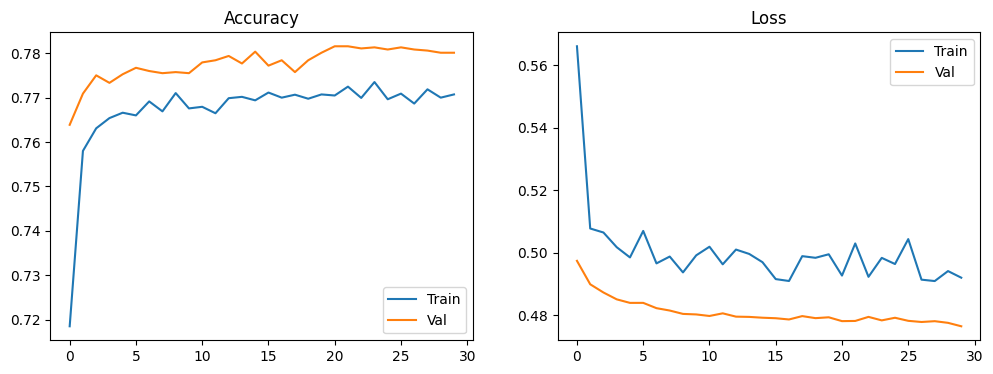

In [32]:
# --- 2. Transform to PyTorch Tensors ---

# Apply scaling/encoding to raw data; .fit on train, .transform on test to avoid data leakage
X_train_np = preprocessor.fit_transform(X_train)
X_test_np = preprocessor.transform(X_test)

# PyTorch needs dense arrays; if One-Hot Encoding created a sparse matrix, we convert it here
if hasattr(X_train_np, 'toarray'):
    X_train_np = X_train_np.toarray()
    X_test_np = X_test_np.toarray()

# Convert NumPy arrays to PyTorch Tensors (standard 32-bit floats for weights)
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
# .reshape(-1, 1) ensures labels are a column vector, matching the model's output shape
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# TensorDataset wraps our features and labels into a single object for easy access
full_ds = TensorDataset(X_train_t, y_train_t)
# Manually split data into 80% training and 20% validation to monitor for overfitting
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

# DataLoaders handle batching (32 rows at a time) and shuffling (prevents the model from learning order)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# --- 3. Model Definition ---

class DisplayNet(nn.Module):
    def __init__(self, input_dim):
        super(DisplayNet, self).__init__()
        # Sequential container for a Feed-Forward Neural Network
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32), # Hidden layer with 32 neurons
            nn.ReLU(),                # Non-linear activation to learn complex patterns
            nn.Dropout(0.5),          # Regularization: randomly kills 50% of neurons to stop overfitting
            nn.Linear(32, 1),         # Output layer: 1 neuron for binary classification
            nn.Sigmoid()              # Compresses output to a 0-1 probability range
        )

    def forward(self, x):
        # Defines the 'forward pass' of data through the network layers
        return self.network(x)

# Initialize model using the dynamic input dimension from our preprocessed data
model = DisplayNet(X_train_np.shape[1])
# Loss: Binary Cross Entropy is the standard for 0/1 classification
criterion = nn.BCELoss()
# Optimizer: Adam with Weight Decay (L2 regularization) to keep weights small and stable
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# --- 4. Training Loop ---

epochs = 30
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train() # Set mode to 'train' so Dropout is ACTIVE
    running_loss, correct = 0.0, 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()   # CLEAR gradients from the previous batch
        outputs = model(inputs) # FORWARD pass: get predictions
        loss = criterion(outputs, labels) # Calculate ERROR
        loss.backward()         # BACKWARD pass: calculate how much each weight contributed to error
        optimizer.step()        # UPDATE weights based on calculated gradients

        running_loss += loss.item() * inputs.size(0)
        correct += ((outputs > 0.5).float() == labels).sum().item()

    # --- Validation Phase ---
    model.eval() # Set mode to 'eval' so Dropout is DISABLED (use full brain for testing)
    v_loss, v_correct = 0.0, 0
    with torch.no_grad(): # DISABLE gradient tracking to save memory and speed up
        for v_inputs, v_labels in val_loader:
            v_outputs = model(v_inputs)
            v_loss += criterion(v_outputs, v_labels).item() * v_inputs.size(0)
            v_correct += ((v_outputs > 0.5).float() == v_labels).sum().item()

    # Log metrics to dictionary for the learning curve plots
    history['loss'].append(running_loss / train_size)
    history['accuracy'].append(correct / train_size)
    history['val_loss'].append(v_loss / val_size)
    history['val_accuracy'].append(v_correct / val_size)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {history['loss'][-1]:.4f} | Val Acc: {history['val_accuracy'][-1]:.4f}")

# --- 5. Evaluation & Visualization ---
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).numpy()
    y_pred = (y_prob > 0.5).astype(int)

print("\n--- Deep Learning Results (PyTorch) ---")
print(f"Accuracy: {(y_pred == y_test.values.reshape(-1,1)).mean():.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Learning curves

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train'); plt.plot(history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train'); plt.plot(history['val_loss'], label='Val')
plt.title('Loss'); plt.legend()
plt.show()

Starting Deep Learning model training...
Epoch 1/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7524 - auc: 0.8070 - loss: 0.5182 - val_accuracy: 0.7811 - val_auc: 0.8383 - val_loss: 0.4735
Epoch 2/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7722 - auc: 0.8278 - loss: 0.4909 - val_accuracy: 0.7847 - val_auc: 0.8432 - val_loss: 0.4659
Epoch 3/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7751 - auc: 0.8312 - loss: 0.4863 - val_accuracy: 0.7855 - val_auc: 0.8465 - val_loss: 0.4655
Epoch 4/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7786 - auc: 0.8361 - loss: 0.4820 - val_accuracy: 0.7862 - val_auc: 0.8474 - val_loss: 0.4626
Epoch 5/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7813 - auc: 0.8400 - loss: 0.4777 - val_accuracy: 0.7862 - val_auc: 0.8483 - val_loss: 0.4605
Epoch 6/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7818 - auc: 0.8369 - loss: 0.4787 - val_accuracy: 0.7872 - val_auc: 0.8477 - val_loss: 0.4600

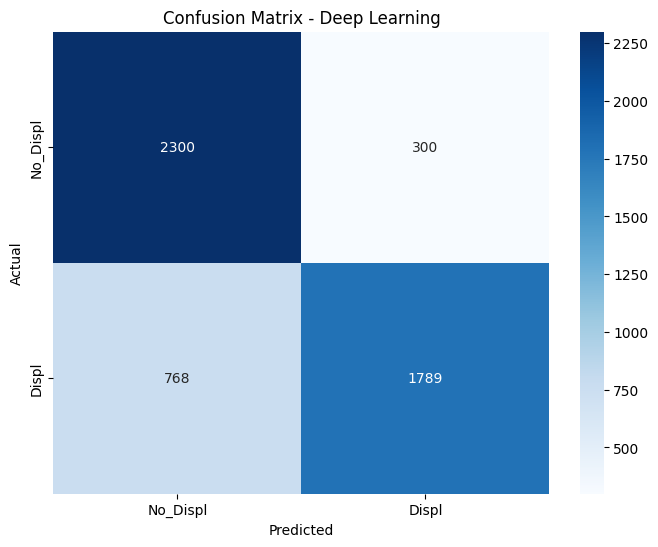

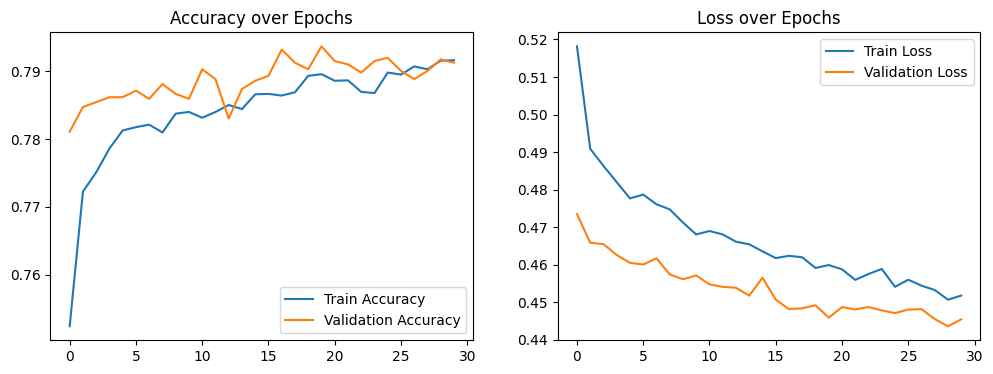

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data preparation (Uses the preprocessor defined earlier)
# Convert data into numpy arrays for Keras
X_train_dl = preprocessor.fit_transform(X_train)
X_test_dl = preprocessor.transform(X_test)

if hasattr(X_train_dl, 'toarray'):
    X_train_dl = X_train_dl.toarray()
    X_test_dl = X_test_dl.toarray()

input_dim = X_train_dl.shape[1]

# 2. Build the Deep Learning model
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# 3. Training
print("Starting Deep Learning model training...")
history = model.fit(X_train_dl, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# 4. Evaluation on the test set
loss, accuracy, auc = model.evaluate(X_test_dl, y_test, verbose=0)
print(f"\n--- Deep Learning Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_dl)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Displ', 'Displ'],
            yticklabels=['No_Displ', 'Displ'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Deep Learning')
plt.show()

# 6. Learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

Starting Deep Learning model training...
Epoch 1/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7388 - auc: 0.7923 - loss: 0.5356 - val_accuracy: 0.7738 - val_auc: 0.8350 - val_loss: 0.4757
Epoch 2/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7648 - auc: 0.8213 - loss: 0.4982 - val_accuracy: 0.7811 - val_auc: 0.8395 - val_loss: 0.4750
Epoch 3/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7701 - auc: 0.8270 - loss: 0.4913 - val_accuracy: 0.7830 - val_auc: 0.8414 - val_loss: 0.4672
Epoch 4/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7741 - auc: 0.8309 - loss: 0.4857 - val_accuracy: 0.7845 - val_auc: 0.8444 - val_loss: 0.4642
Epoch 5/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7761 - auc: 0.8335 - loss: 0.4825 - val_accuracy: 0.7852 - val_auc: 0.8456 - val_loss: 0.4628
Epoch 6/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7799 - auc: 0.8367 - loss: 0.4789 - val_accuracy: 0.7876 - val_auc: 0.8483 - val_loss: 0.4610

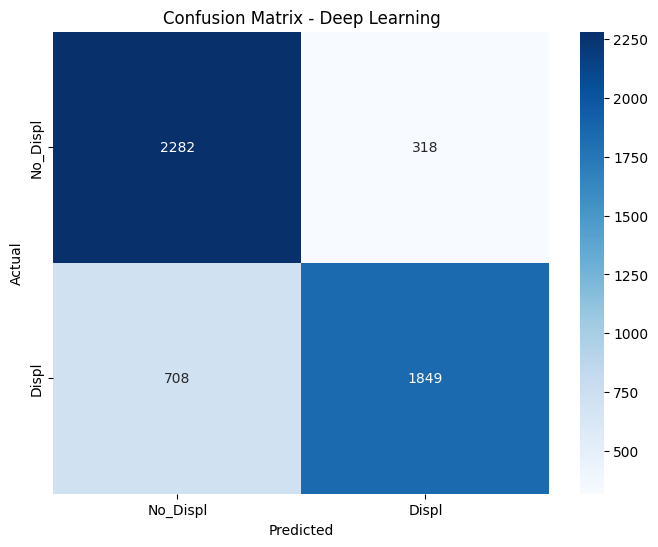

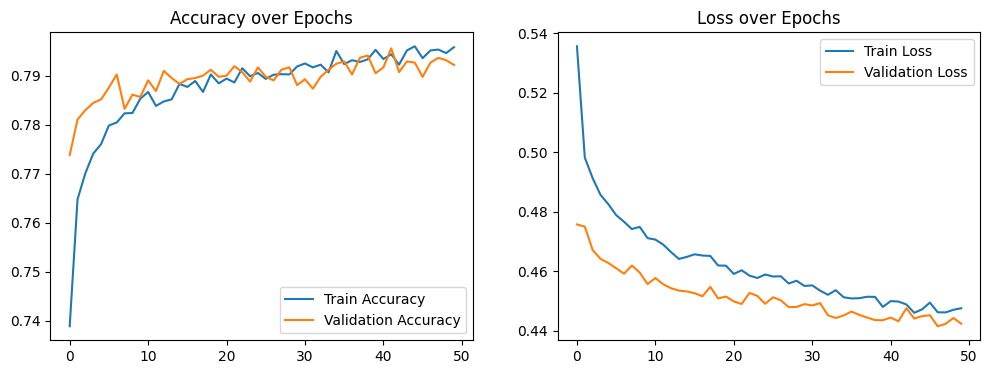

In [6]:
# Convert data into numpy arrays for Keras
X_train_dl = preprocessor.fit_transform(X_train)
X_test_dl = preprocessor.transform(X_test)

if hasattr(X_train_dl, 'toarray'):
    X_train_dl = X_train_dl.toarray()
    X_test_dl = X_test_dl.toarray()

input_dim = X_train_dl.shape[1]

# 2. Build the Deep Learning model
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# 3. Training
print("Starting Deep Learning model training...")
history = model.fit(X_train_dl, y_train,
                    epochs=50,
                    batch_size=50,
                    validation_split=0.2,
                    verbose=1)

# 4. Evaluation on the test set
loss, accuracy, auc = model.evaluate(X_test_dl, y_test, verbose=0)
print(f"\n--- Deep Learning Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_dl)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Displ', 'Displ'],
            yticklabels=['No_Displ', 'Displ'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Deep Learning')
plt.show()

# 6. Learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

Entraînement du modèle Deep Learning Avancé...
Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7164 - auc: 0.7591 - loss: 0.5712 - val_accuracy: 0.7658 - val_auc: 0.8251 - val_loss: 0.5234
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7553 - auc: 0.8096 - loss: 0.5124 - val_accuracy: 0.7758 - val_auc: 0.8348 - val_loss: 0.4780
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7661 - auc: 0.8202 - loss: 0.4987 - val_accuracy: 0.7821 - val_auc: 0.8406 - val_loss: 0.4712
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7693 - auc: 0.8233 - loss: 0.4941 - val_accuracy: 0.7828 - val_auc: 0.8431 - val_loss: 0.4667
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7733 - auc: 0.8223 - loss: 0.4941 - val_accuracy: 0.7830 - val_auc: 0.8443 - val_loss: 0.4664
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7746 - auc: 0.8262 - loss: 0.4910 - val_accuracy: 0.7855 - val_auc: 0.8472 - val_

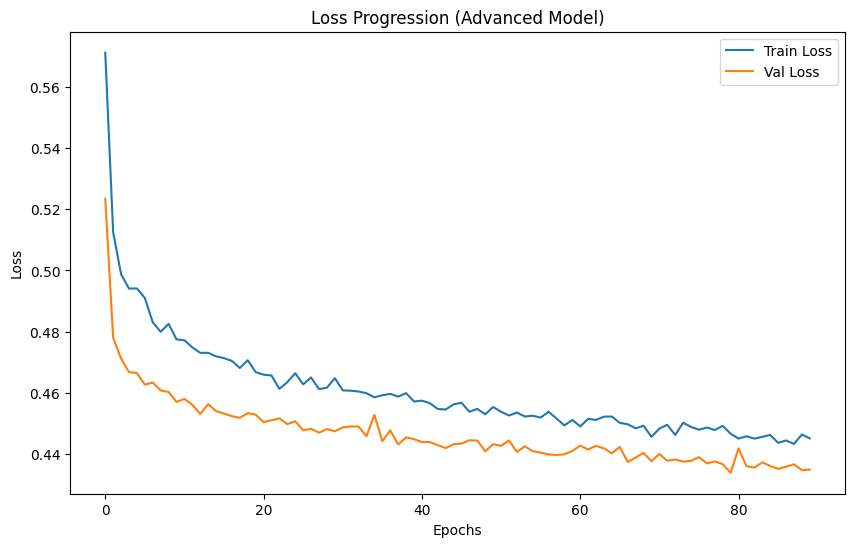

In [7]:
# On utilise le préprocesseur déjà défini dans votre notebook
X_train_adv = preprocessor.fit_transform(X_train)
X_test_adv = preprocessor.transform(X_test)

if hasattr(X_train_adv, 'toarray'):
    X_train_adv = X_train_adv.toarray()
    X_test_adv = X_test_adv.toarray()

input_dim = X_train_adv.shape[1]

# 2. Architecture Avancée
# Ce modèle est plus profond et utilise la Batch Normalization pour plus de stabilité
model_adv = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_adv.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# 3. Early Stopping (Arrêt précoce pour éviter le surapprentissage)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 4. Entraînement
print("Entraînement du modèle Deep Learning Avancé...")
history_adv = model_adv.fit(X_train_adv, y_train,
                            epochs=100,
                            batch_size=64,
                            validation_split=0.2,
                            callbacks=[early_stopping],
                            verbose=1)

# 5. Évaluation
loss, accuracy, auc = model_adv.evaluate(X_test_adv, y_test, verbose=0)
print(f"\n--- Résultats Modèle Avancé ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

# Prédictions et Rapport
y_pred_adv = (model_adv.predict(X_test_adv) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adv))

# 6. Visualisation de la perte (Loss)
plt.figure(figsize=(10, 6))
plt.plot(history_adv.history['loss'], label='Train Loss')
plt.plot(history_adv.history['val_loss'], label='Val Loss')
plt.title('Loss Progression (Advanced Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Model Training and Comparison**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import joblib
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             classification_report)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42)  # important pour predict_proba
}

In [ ]:
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'AUC': auc_score,
        'Pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.7689
AUC: 0.8249
              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2600
           1       0.84      0.66      0.74      2557

    accuracy                           0.77      5157
   macro avg       0.78      0.77      0.77      5157
weighted avg       0.78      0.77      0.77      5157


--- Random Forest ---
Accuracy: 0.8420
AUC: 0.9109
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157


--- Decision Tree ---
Accuracy: 0.8020
AUC: 0.8033
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2600
           1       0.79      0.82      0.80      2557

    accuracy        



### **Model Performance Comparison**

| Model | Accuracy | AUC Score | Precision (Avg) | Recall (Avg) | F1-Score (Avg) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest** | **0.8420** | **0.9109** | **0.84** | **0.84** | **0.84** |
| **KNN** | 0.8096 | 0.8786 | 0.81 | 0.81 | 0.81 |
| **Decision Tree** | 0.8020 | 0.8033 | 0.80 | 0.80 | 0.80 |
| **Gradient Boosting** | 0.8012 | 0.8744 | 0.81 | 0.80 | 0.80 |
| **SVM** | 0.7809 | 0.8320 | 0.80 | 0.78 | 0.78 |
| **Logistic Regression** | 0.7689 | 0.8249 | 0.78 | 0.77 | 0.77 |



### **Model Analysis & Discussion**

> **Analysis:** > The benchmarking results reveal that **Random Forest** is the most robust model for this dataset, achieving the highest **Accuracy (84.2%)** and **AUC (91.1%)**. These metrics suggest that the ensemble approach of Random Forest is highly effective at capturing the non-linear relationships within the sales data ($X1$ to $X6$) and retailer behaviors ($X5$).

> While **KNN** and **Decision Trees** performed well (exceeding 80% accuracy), they lack the generalization power of the Random Forest. **Logistic Regression** and **SVM** showed lower recall for the "Display" class (Class 1), indicating they struggled more with false negatives compared to the tree-based models.

> **Conclusion:** > Based on the F1-score balance and the high area under the curve (AUC), the **Random Forest** model is selected as the primary predictive tool for identifying product display opportunities.


In [ ]:
best_model_name = max(results, key=lambda x: results[x]['AUC'])
best_pipeline = results[best_model_name]['Pipeline']

joblib.dump(best_pipeline, '/content/best_display_model.pkl')

print(f"\n best model: {best_model_name}")


 best model: Random Forest


# **In-depth Evaluation**

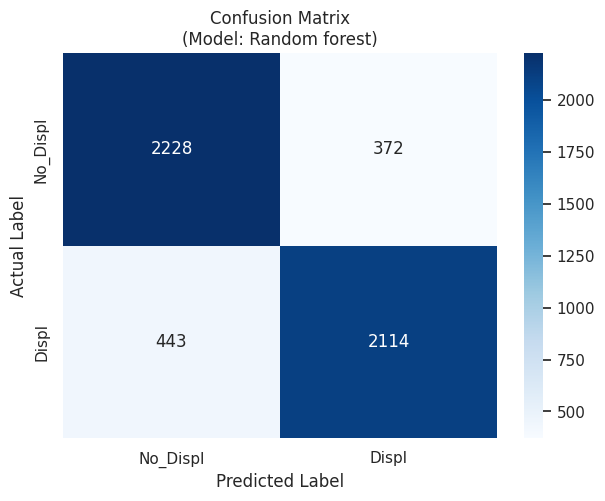

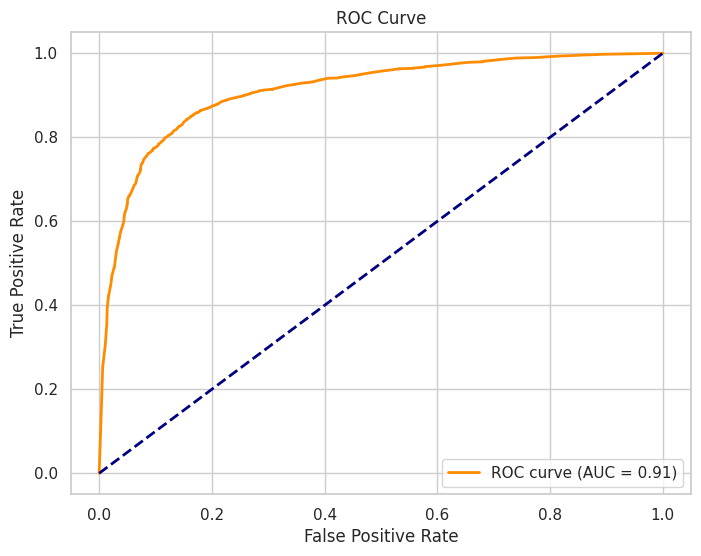

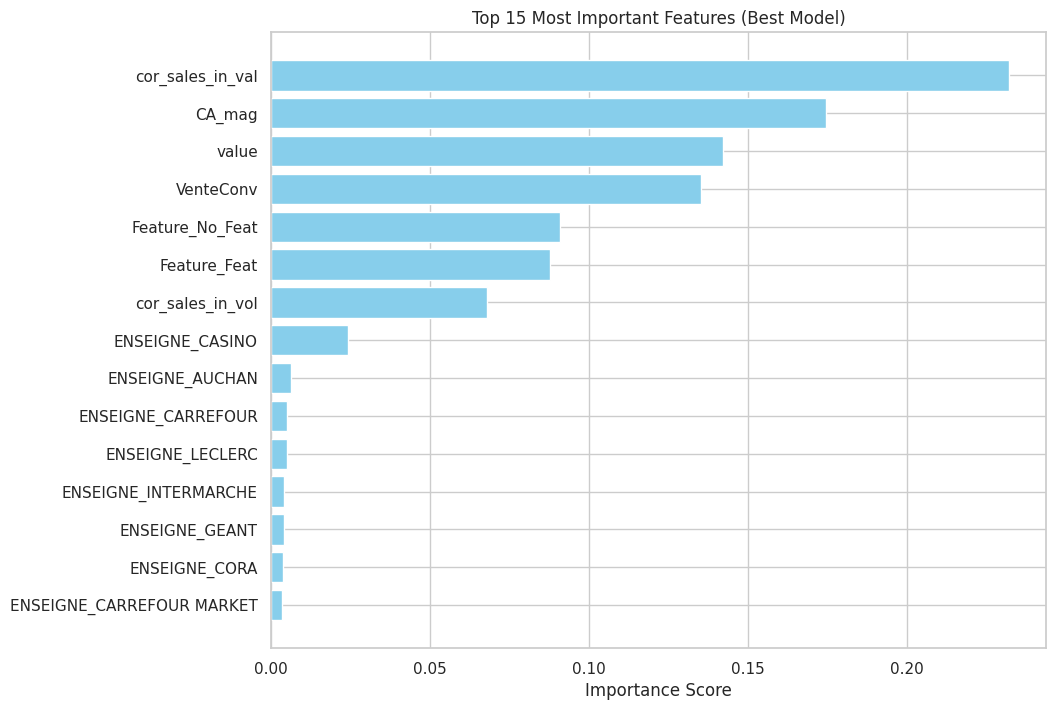

--- Classification Report for /content/best_display_model.pkl ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157



In [ ]:
model_path = '/content/best_display_model.pkl'
best_pipeline = joblib.load(model_path)
# We use the loaded pipeline to predict on the test set
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# --- STEP 3: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Displ', 'Displ'],
            yticklabels=['No_Displ', 'Displ'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix\n(Model: Random forest)')
plt.show()

# --- STEP 4: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- STEP 5: Feature Importance ---
# Note: This assumes the best model was Random Forest or a Tree-based model
classifier = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline.named_steps['preprocessor']

# Retrieve categorical feature names from the OneHotEncoder step
ohe = preprocessor.named_transformers_['cat']
cat_names = ohe.get_feature_names_out(['ENSEIGNE', 'Feature']).tolist()
numerical_features = ['cor_sales_in_vol', 'cor_sales_in_val', 'CA_mag', 'value', 'VenteConv']
feature_names = numerical_features + cat_names

importances = classifier.feature_importances_
sorted_idx = importances.argsort()[-15:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='skyblue')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Top 15 Most Important Features (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# --- STEP 6: Classification Report ---
print(f"--- Classification Report for {model_path} ---")
print(classification_report(y_test, y_pred))


===== Evaluation : Logistic Regression =====


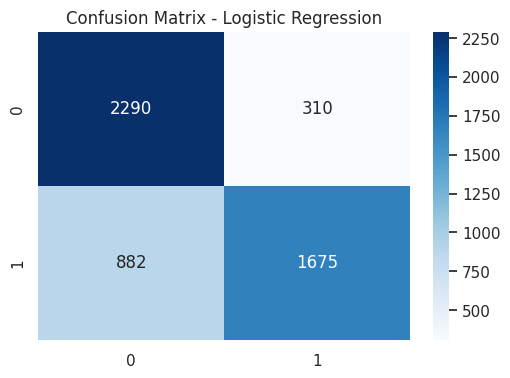

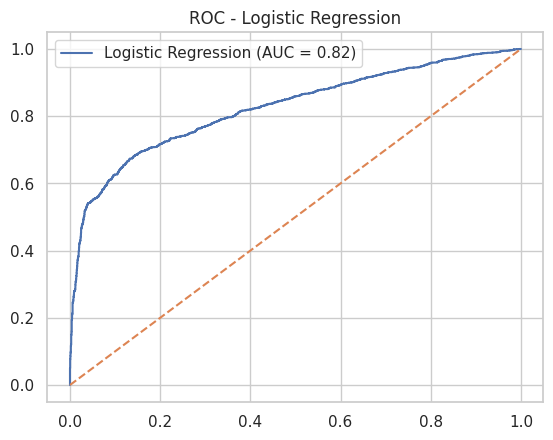

              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2600
           1       0.84      0.66      0.74      2557

    accuracy                           0.77      5157
   macro avg       0.78      0.77      0.77      5157
weighted avg       0.78      0.77      0.77      5157


===== Evaluation : Random Forest =====


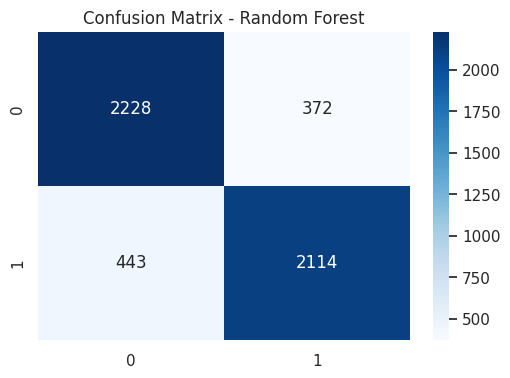

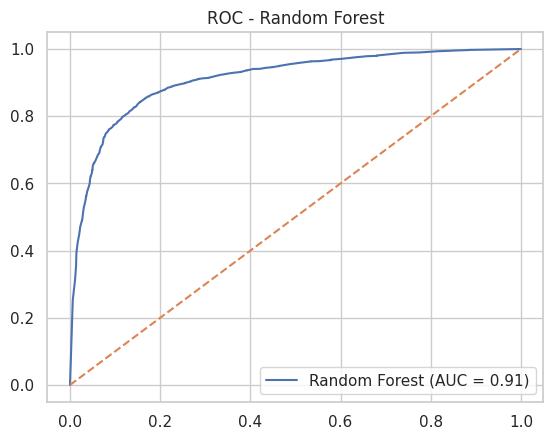

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157


===== Evaluation : Decision Tree =====


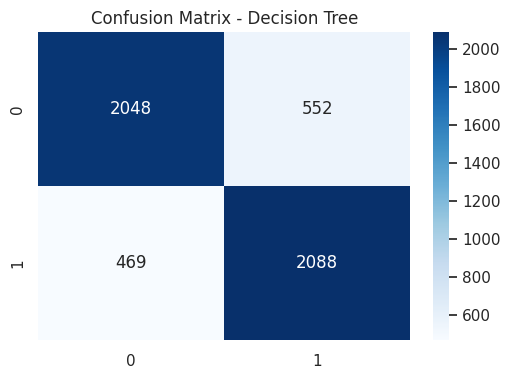

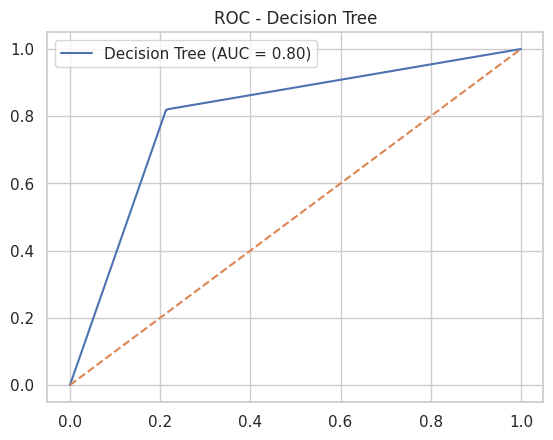

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2600
           1       0.79      0.82      0.80      2557

    accuracy                           0.80      5157
   macro avg       0.80      0.80      0.80      5157
weighted avg       0.80      0.80      0.80      5157


===== Evaluation : Gradient Boosting =====


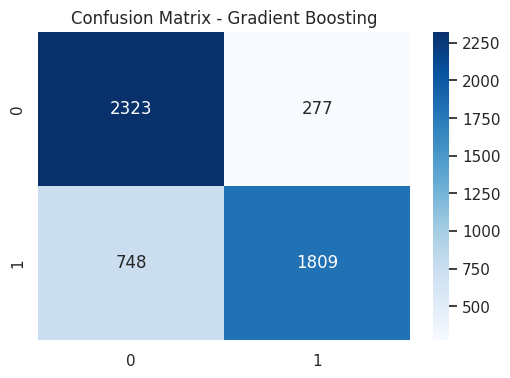

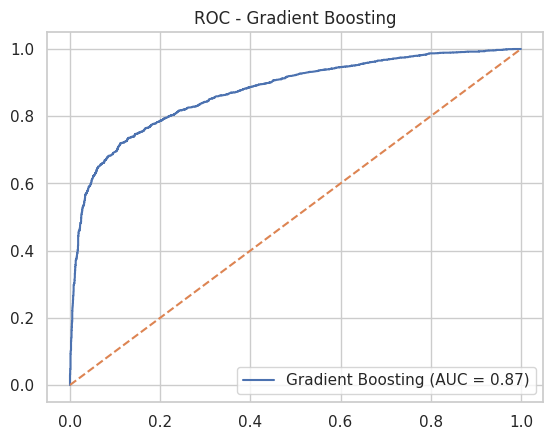

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      2600
           1       0.87      0.71      0.78      2557

    accuracy                           0.80      5157
   macro avg       0.81      0.80      0.80      5157
weighted avg       0.81      0.80      0.80      5157


===== Evaluation : KNN =====


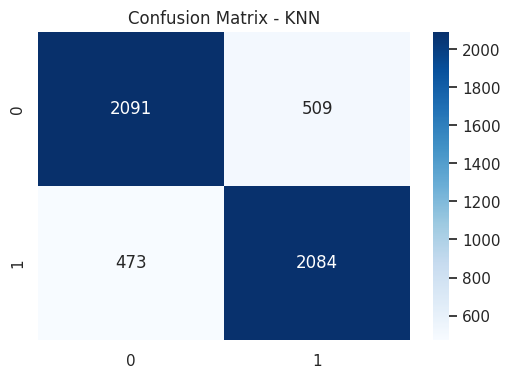

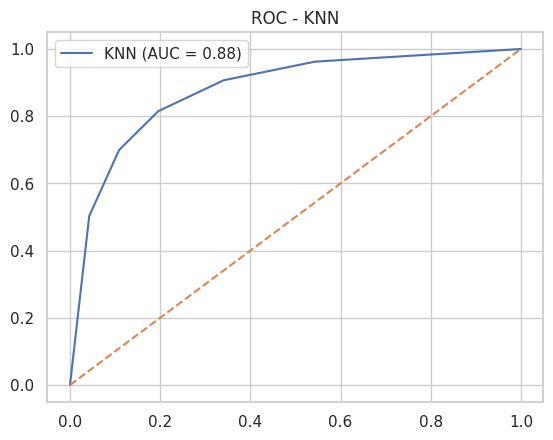

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2600
           1       0.80      0.82      0.81      2557

    accuracy                           0.81      5157
   macro avg       0.81      0.81      0.81      5157
weighted avg       0.81      0.81      0.81      5157


===== Evaluation : SVM =====


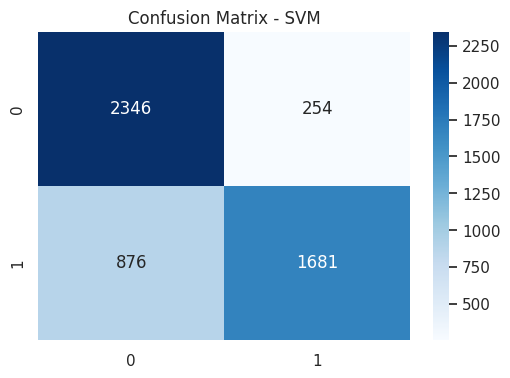

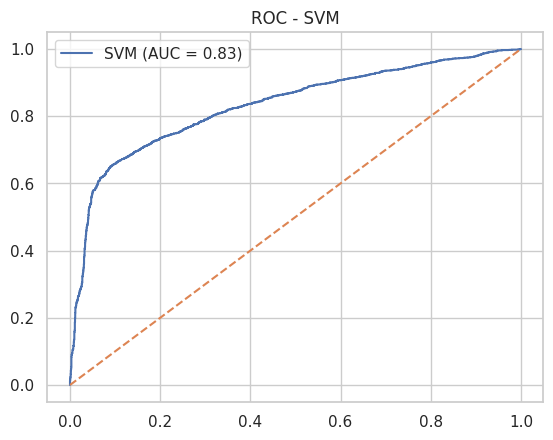

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      2600
           1       0.87      0.66      0.75      2557

    accuracy                           0.78      5157
   macro avg       0.80      0.78      0.78      5157
weighted avg       0.80      0.78      0.78      5157



In [ ]:
for name, res in results.items():
    print(f"\n===== Evaluation : {name} =====")

    y_pred = res['y_pred']
    y_prob = res['y_prob']
    pipeline = res['Pipeline']

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f'ROC - {name}')
    plt.show()

    print(classification_report(y_test, y_pred))

In [ ]:
import joblib
joblib.dump(best_pipeline, '/content/best_display_model.pkl', compress=3)

['/content/best_display_model.pkl']